# About Dataset 4


At LOL Bank Pvt. Ltd., ensuring the safety and integrity of economic transactions is a top priority. With increasingly more on line transactions and digital banking activities, fraudulent transactions have end up a good sized danger to both the financial institution and its customers. Fraudulent activities, along with unauthorized account get right of entry to, identification robbery, and suspicious transaction patterns, bring about economic losses and harm to patron agree with.

To cope with this developing subject, LOL Bank Pvt. Ltd. Is in search of a strategy to stumble on and save you fraudulent transactions in real time. This includes analyzing ancient transaction records, consisting of account info, transaction quantities, service provider records, and time stamps, to pick out patterns indicative of fraudulent conduct. The intention is to construct a robust fraud detection gadget that may distinguish among legitimate transactions and probably fraudulent ones, with minimal fake positives.

The answer must incorporate device learning algorithms to study from transaction history, allowing the machine to become aware of rising fraud strategies and adapt to evolving threats. The gadget must be able to flag suspicious transactions in real time, providing bank employees with actionable insights to take activate action. By enhancing fraud detection abilities, LOL Bank Pvt. Ltd. Objectives to shield patron belongings, lessen financial losses, and keep its reputation as a secure and honest economic organization.

﻿Here are the information of the columns:

1. **Customer_ID**: A particular identifier for every customer within the bank's system.
2. **Customer_Name**: The name of the consumer making the transaction.
3. **Gender**: The gender of the consumer (e.G., Male, Female, Other).
4. **Age**: The age of the consumer at the time of the transaction.
5. **State**: The nation in which the patron resides.
6. **City**: The metropolis wherein the client is living.
7. **Bank_Branch**: The specific financial institution branch wherein the consumer holds their account.
8. **Account_Type**: The kind of account held with the aid of the customer (e.G., Savings, Checking).
9. **Transaction_ID**: A particular identifier for each transaction.
10. **Transaction_Date**: The date on which the transaction passed off.
11. **Transaction_Time**: The specific time the transaction became initiated.
12. **Transaction_Amount**: The financial value of the transaction.
12. **Merchant_ID**: A particular identifier for the merchant worried within the transaction.
14. **Transaction_Type**: The nature of the transaction (e.G., Withdrawal, Deposit, Transfer).
15. **Merchant_Category**: The class of the merchant (e.G., Retail, Online, Travel).
16. **Account_Balance**: The balance of the customer's account after the transaction.
17. **Transaction_Device**: The tool utilized by the consumer to perform the transaction (e.G., Mobile, Desktop).
18. **Transaction_Location**: The geographical vicinity (e.G., latitude, longitude) of the transaction.
19. **Device_Type**: The kind of device used for the transaction (e.G., Smartphone, Laptop).
20. **Is_Fraud**: A binary indicator (1 or zero) indicating whether or not the transaction is fraudulent or now not.
21. **Transaction_Currency**: The currency used for the transaction (e.G., USD, EUR).
22. **Customer_Contact**: The contact variety of the client.
23. **Transaction_Description**: A brief description of the transaction (e.G., buy, switch).
24. **Customer_Email**: The e-mail cope with related to the consumer's account.

These column descriptions give a clear expertise of the facts as a way to be used for fraud detection analysis.

In [2]:
pip install kagglehub


   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   -------------------- ------------------- 1/2 [kagglehub]
   ---------------------------------------- 2/2 [kagglehub]

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import kagglehub
import pandas as pd #required for dealing with dataframes
import numpy as np  #required for data processing
import random#
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score,
                             precision_score, recall_score, mean_absolute_error,
                             mean_squared_error, root_mean_squared_error, r2_score)

from data_issues_generator import introduce_data_issues
import MyOwnModule
import importlib

importlib.reload(MyOwnModule)

filename = "Bank_Transaction_Fraud_Detection.csv"
#check if the file already exists to avoid needed internet to download it or changing the code to just use it
if MyOwnModule.file_exists(filename):
    print("File "+ filename + " exists in the working directory. No need to download it from Kaggle")
    df = pd.read_csv(filename)
else:
    path = kagglehub.dataset_download("marusagar/bank-transaction-fraud-detection")
    
    print("Dataset path:", path)
    
    files = os.listdir(path)
    print("Files in dataset:", files)
    
    file_path = os.path.join(path, filename)
    df = pd.read_csv(file_path)

print("First 5 records:")
print(df.head())
##add this change to test

File Bank_Transaction_Fraud_Detection.csv exists in the working directory. No need to download it from Kaggle
First 5 records:
                            Customer_ID        Customer_Name  Gender  Age  \
0  d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e           Osha Tella    Male   60   
1  7c14ad51-781a-4db9-b7bd-67439c175262      Hredhaan Khosla  Female   51   
2  3a73a0e5-d4da-45aa-85f3-528413900a35       Ekani Nazareth    Male   20   
3  7902f4ef-9050-4a79-857d-9c2ea3181940  Yamini Ramachandran  Female   57   
4  3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9         Kritika Rege  Female   43   

         State                City                Bank_Branch Account_Type  \
0       Kerala  Thiruvananthapuram  Thiruvananthapuram Branch      Savings   
1  Maharashtra              Nashik              Nashik Branch     Business   
2        Bihar           Bhagalpur           Bhagalpur Branch      Savings   
3   Tamil Nadu             Chennai             Chennai Branch     Business   
4       Punjab      

In [7]:
print("Shape:", df.shape)

Shape: (200000, 24)


In [9]:
#%% 0. ADDING DATA ISSUES

"""
    Introduce data quality issues into the DataFrame for practice.

    Parameters
    ----------
    df : pandas.DataFrame
        The clean DataFrame to corrupt
    duplicate_pct : float, default=0.05
        Percentage of rows to duplicate (0.05 = 5%)
    missing_pct : float, default=0.05
        Percentage of missing values to introduce across features
    random_state : int, default=42
        Random seed for reproducibility

    Returns
    -------
    pandas.DataFrame
        DataFrame with introduced data issues
"""
df = introduce_data_issues(df)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210000 entries, 0 to 209999
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Customer_ID              210000 non-null  object 
 1   Customer_Name            210000 non-null  object 
 2   Gender                   208750 non-null  object 
 3   Age                      208760 non-null  float64
 4   State                    210000 non-null  object 
 5   City                     210000 non-null  object 
 6   Bank_Branch              210000 non-null  object 
 7   Account_Type             208750 non-null  object 
 8   Transaction_ID           210000 non-null  object 
 9   Transaction_Date         210000 non-null  object 
 10  Transaction_Time         210000 non-null  object 
 11  Transaction_Amount       208777 non-null  float64
 12  Merchant_ID              210000 non-null  object 
 13  Transaction_Type         208750 non-null  object 
 14  Merc

In [26]:
print(f"Number of duplicated rows:{int(df.duplicated().value_counts()[True])}")

Number of duplicated rows:7330


In [ ]:
#%% 1. DATA PREPARATION

# Make sure the Is_fraud is converted to object/categorical
# And no longer included in numerical variables
Numerical_Variables = df.select_dtypes(include=['int64', 'float64']).columns
Categorical_Variables = df.select_dtypes(include=['object', 'category']).columns
print(df.nunique())

Gender                          2
Age                            53
Account_Type                    3
Transaction_Amount         197978
Transaction_Type                5
Merchant_Category               6
Account_Balance            197954
Transaction_Device             20
Transaction_Location          148
Device_Type                     4
Is_Fraud                        2
Transaction_Currency            1
Transaction_Description       172
dtype: int64


In [ ]:

#drop only after the duplicate treatment
#convert the transaction time into DayOfWeek, TimeOfDay no need for ordinality by definition of date and time

df.drop(columns = ['Customer_ID','Customer_Email','Customer_Contact','Customer_Name','Transaction_ID','Merchant_ID','Transaction_Time','City','State','Bank_Branch','Transaction_Date'], inplace = True)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Gender                   200000 non-null  object 
 1   Age                      200000 non-null  int64  
 2   Account_Type             200000 non-null  object 
 3   Transaction_Amount       200000 non-null  float64
 4   Transaction_Type         200000 non-null  object 
 5   Merchant_Category        200000 non-null  object 
 6   Account_Balance          200000 non-null  float64
 7   Transaction_Device       200000 non-null  object 
 8   Transaction_Location     200000 non-null  object 
 9   Device_Type              200000 non-null  object 
 10  Is_Fraud                 200000 non-null  int64  
 11  Transaction_Currency     200000 non-null  object 
 12  Transaction_Description  200000 non-null  object 
dtypes: float64(2), int64(2), object(9)
memory usage: 19.8+ MB
N

In [ ]:
df['Is_Fraud'] = df['Is_Fraud'].astype('object')
print(df.dtypes)

Gender                      object
Age                          int64
Account_Type                object
Transaction_Amount         float64
Transaction_Type            object
Merchant_Category           object
Account_Balance            float64
Transaction_Device          object
Transaction_Location        object
Device_Type                 object
Is_Fraud                    object
Transaction_Currency        object
Transaction_Description     object
dtype: object


In [ ]:
print(df.columns)

Index(['Gender', 'Age', 'Account_Type', 'Transaction_Amount',
       'Transaction_Type', 'Merchant_Category', 'Account_Balance',
       'Transaction_Device', 'Transaction_Location', 'Device_Type', 'Is_Fraud',
       'Transaction_Currency', 'Transaction_Description'],
      dtype='object')


In [ ]:
print(df.describe())

                 Age  Transaction_Amount  Account_Balance
count  200000.000000       200000.000000    200000.000000
mean       44.015110        49538.015554     52437.988784
std        15.288774        28551.874004     27399.507128
min        18.000000           10.290000      5000.820000
25%        31.000000        24851.345000     28742.395000
50%        44.000000        49502.440000     52372.555000
75%        57.000000        74314.625000     76147.670000
max        70.000000        98999.980000     99999.950000


In [ ]:
df.isna().sum()

,0
Gender,27
Age,13
Account_Type,22
Transaction_Amount,22
Transaction_Type,23
Merchant_Category,25
Account_Balance,25
Transaction_Device,28
Transaction_Location,22
Device_Type,30


In [ ]:
# Handling missing values
df.dropna(inplace=True)
df


,Gender,Age,Account_Type,Transaction_Amount,Transaction_Type,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Currency,Transaction_Description
0,Male,60.0,Savings,32415.45,Transfer,Restaurant,74557.27,Voice Assistant,"Thiruvananthapuram, Kerala",POS,0,INR,Bitcoin transaction
1,Female,51.0,Business,43622.60,Bill Payment,Restaurant,74622.66,POS Mobile Device,"Nashik, Maharashtra",Desktop,0,INR,Grocery delivery
2,Male,20.0,Savings,63062.56,Bill Payment,Groceries,66817.99,ATM,"Bhagalpur, Bihar",Desktop,0,INR,Mutual fund investment
3,Female,57.0,Business,14000.72,Debit,Entertainment,58177.08,POS Mobile App,"Chennai, Tamil Nadu",Mobile,0,INR,Food delivery
4,Female,43.0,Savings,18335.16,Transfer,Entertainment,16108.56,Virtual Card,"Amritsar, Punjab",Mobile,0,INR,Debt repayment
...,...,...,...,...,...,...,...,...,...,...,...,...,...
200195,Male,49.0,Savings,53624.04,Transfer,Restaurant,35493.23,Desktop/Laptop,"Shimla, Himachal Pradesh",POS,0,INR,Restaurant dining
200196,Female,18.0,Business,65109.05,Credit,Groceries,8230.72,Bank Branch,"Faridabad, Haryana",ATM,0,INR,Medical treatment payment
200197,Male,54.0,Business,43290.12,Transfer,Entertainment,80768.21,Self-service Banking Machine,"Kavaratti, Lakshadweep",POS,0,INR,Personal finance consulting
200198,Female,62.0,Business,27262.57,Debit,Groceries,32989.65,Desktop/Laptop,"Mahe, Puducherry",POS,1,INR,Long-distance transport


In [ ]:
df.isna().sum()

,0
Gender,0
Age,0
Account_Type,0
Transaction_Amount,0
Transaction_Type,0
Merchant_Category,0
Account_Balance,0
Transaction_Device,0
Transaction_Location,0
Device_Type,0


In [ ]:
# Check for duplicates
print(f"Number of duplicate rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
df

Number of duplicate rows: 200


,Gender,Age,Account_Type,Transaction_Amount,Transaction_Type,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Currency,Transaction_Description
0,Male,60.0,Savings,32415.45,Transfer,Restaurant,74557.27,Voice Assistant,"Thiruvananthapuram, Kerala",POS,0,INR,Bitcoin transaction
1,Female,51.0,Business,43622.60,Bill Payment,Restaurant,74622.66,POS Mobile Device,"Nashik, Maharashtra",Desktop,0,INR,Grocery delivery
2,Male,20.0,Savings,63062.56,Bill Payment,Groceries,66817.99,ATM,"Bhagalpur, Bihar",Desktop,0,INR,Mutual fund investment
3,Female,57.0,Business,14000.72,Debit,Entertainment,58177.08,POS Mobile App,"Chennai, Tamil Nadu",Mobile,0,INR,Food delivery
4,Female,43.0,Savings,18335.16,Transfer,Entertainment,16108.56,Virtual Card,"Amritsar, Punjab",Mobile,0,INR,Debt repayment
...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,Female,55.0,Business,98513.74,Credit,Restaurant,37475.11,Desktop/Laptop,"Diu, Dadra and Nagar Haveli and Daman and Diu",ATM,0,INR,ATM withdrawal
199996,Male,51.0,Business,40593.55,Withdrawal,Groceries,53037.20,ATM,"Kangpokpi, Manipur",ATM,0,INR,Subscription box
199997,Female,41.0,Savings,61579.70,Withdrawal,Health,96225.36,ATM,"Chandigarh, Chandigarh",Desktop,0,INR,Charity donation
199998,Female,28.0,Checking,39488.22,Debit,Electronics,89599.90,Voice Assistant,"Nizamabad, Telangana",Desktop,0,INR,Tourist attraction payment


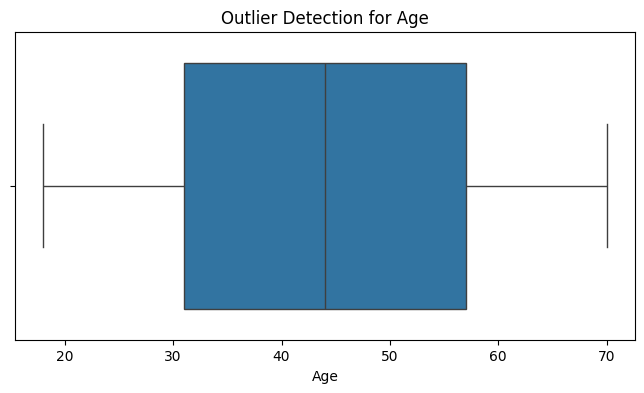

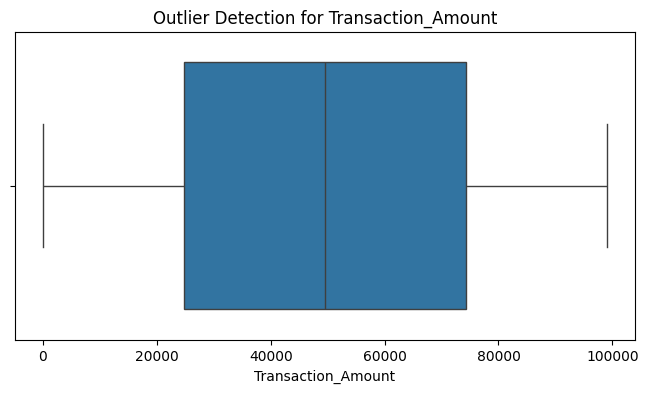

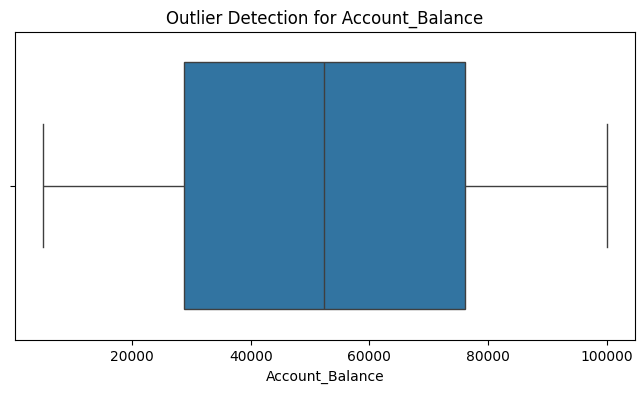

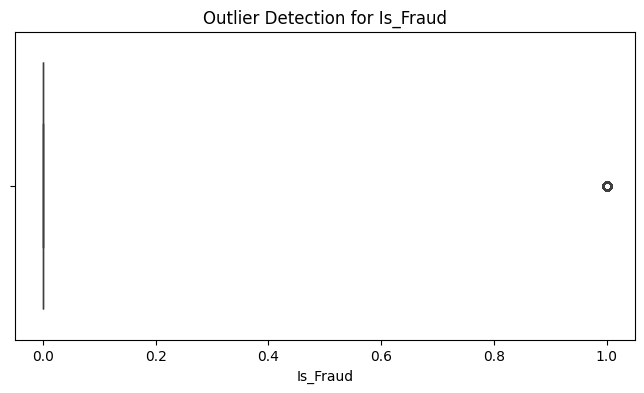

In [ ]:
# Outlier Detection using Boxplots
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
Numerical_Variables = df.select_dtypes(include=['int64', 'float64']).columns
Categorical_Variables = df.select_dtypes(include=['object', 'category']).columns
for col in Numerical_Variables:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Outlier Detection for {col}')
    plt.show()


In [ ]:
#outliers treatment may not be applicable

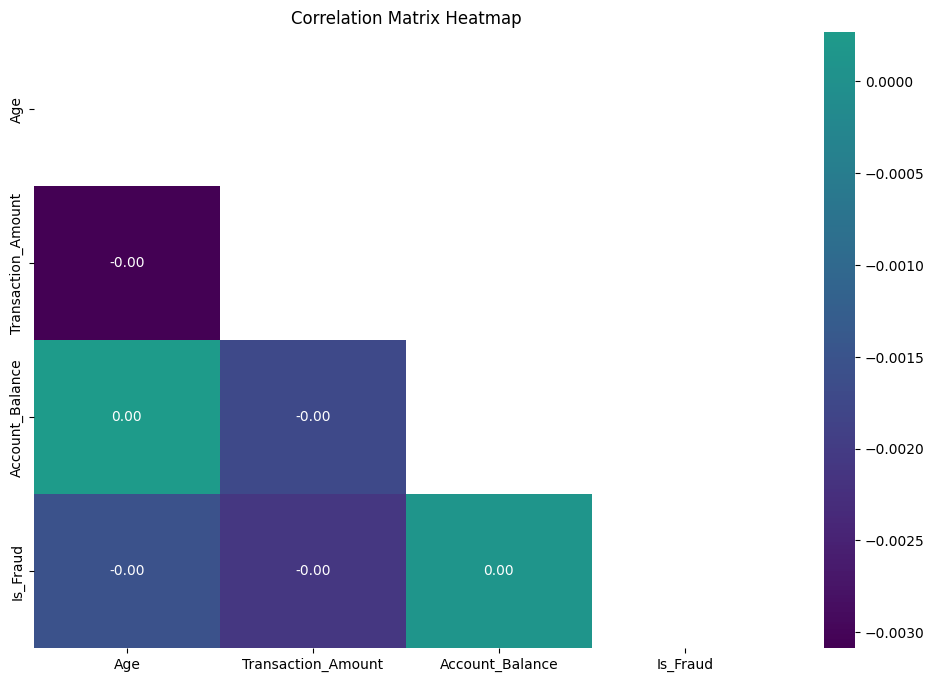

Account_Balance       0.000125
Age                  -0.001517
Transaction_Amount   -0.002100
Name: Is_Fraud, dtype: float64


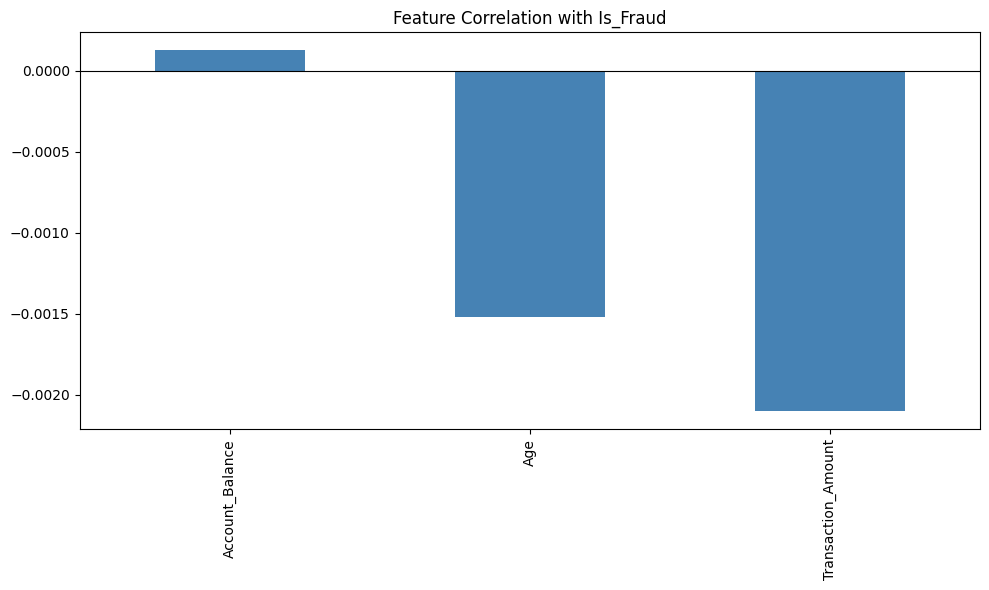

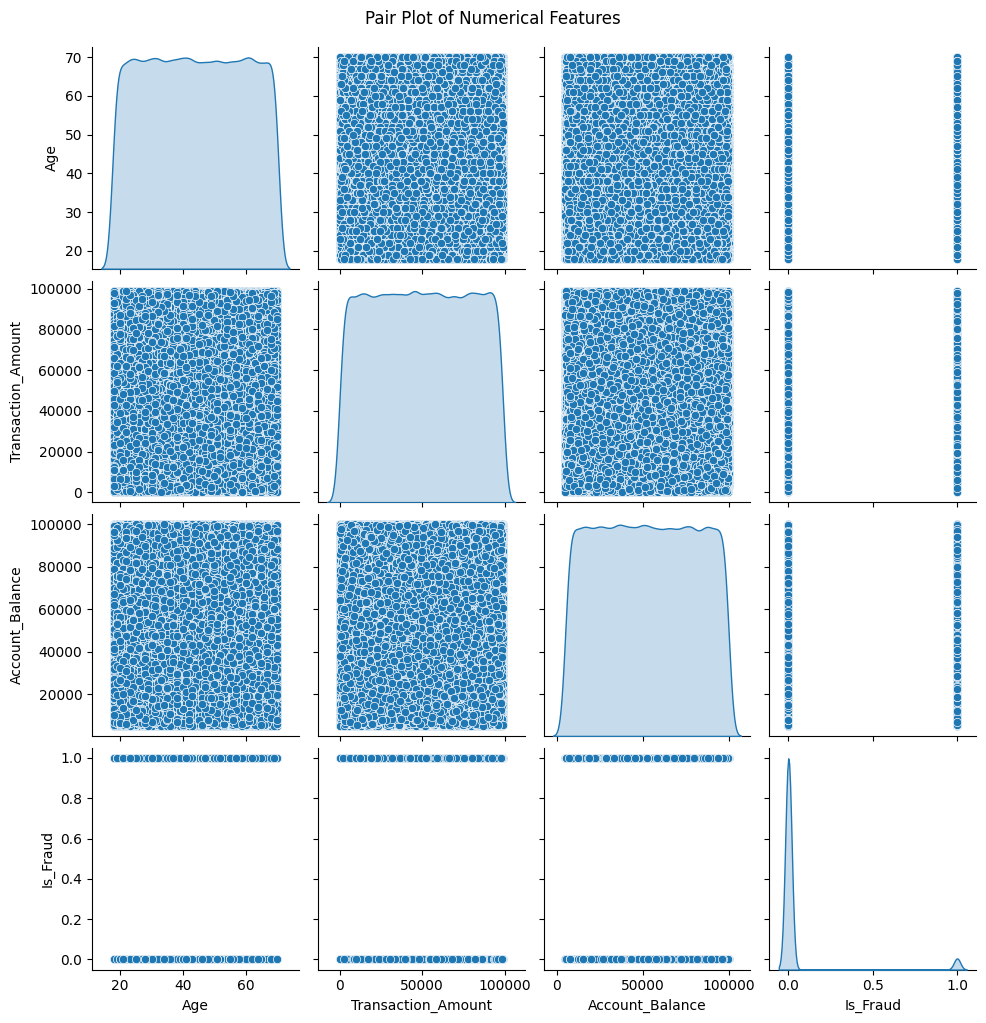

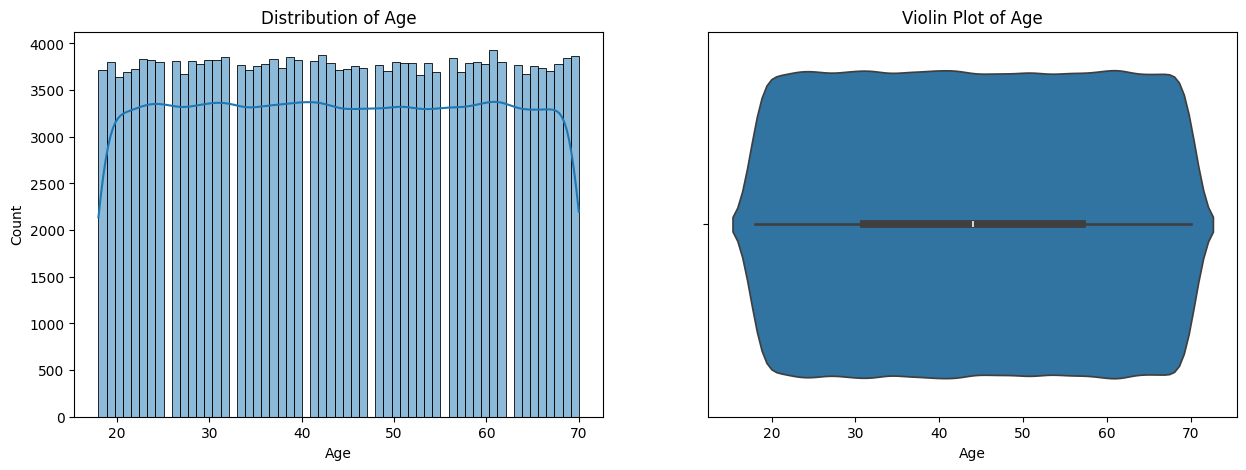

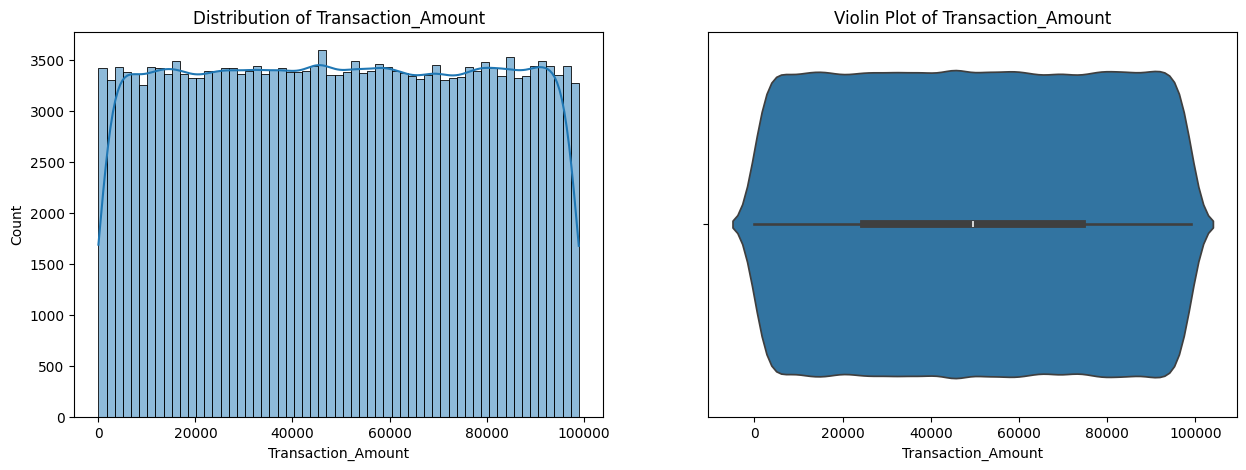

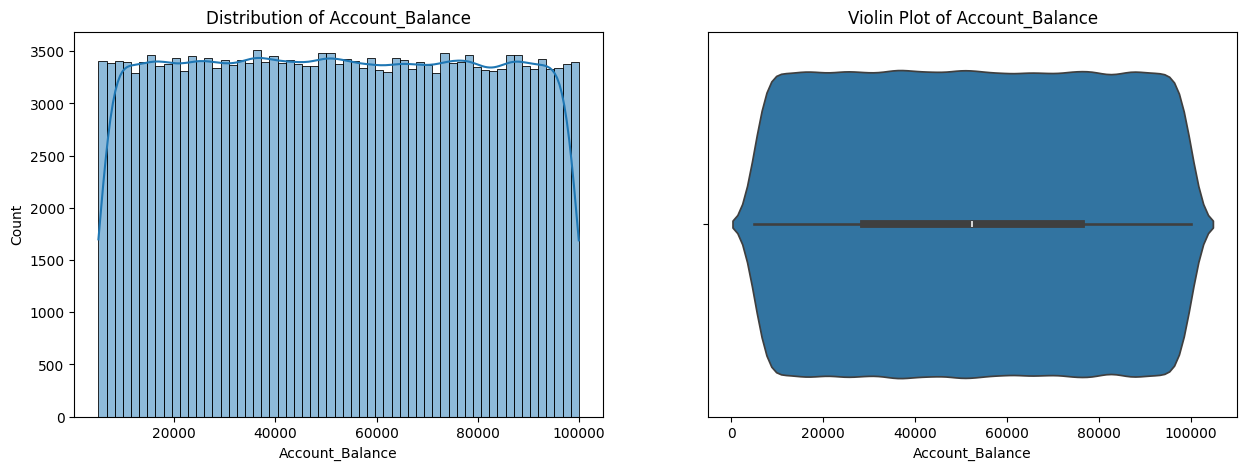

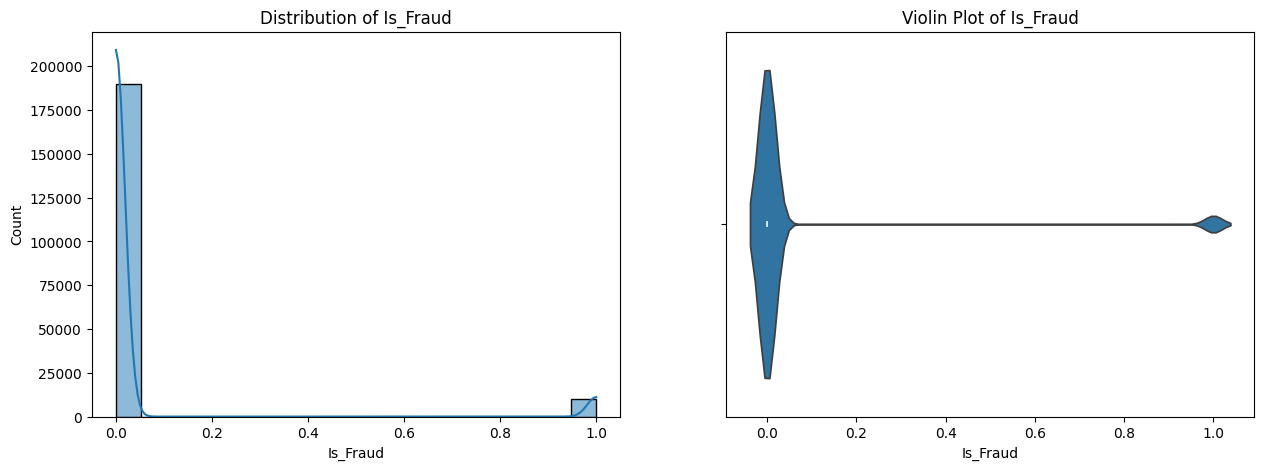

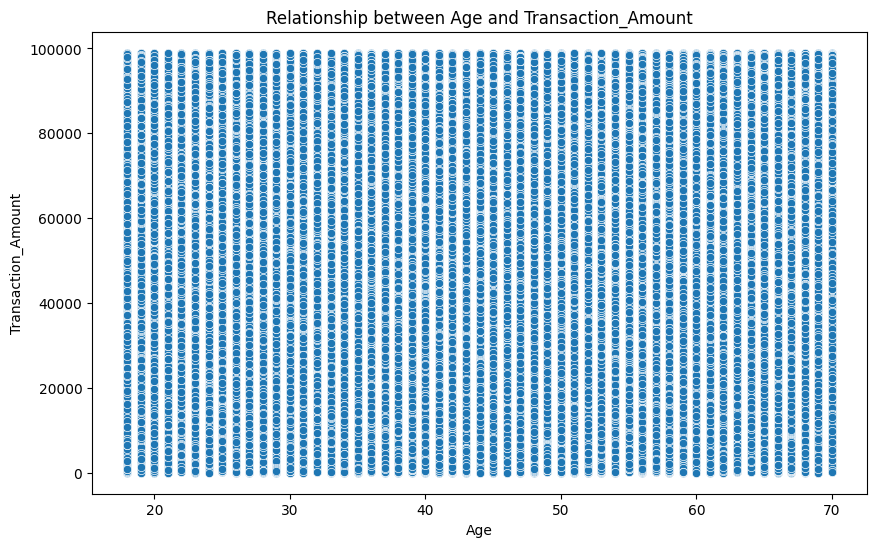

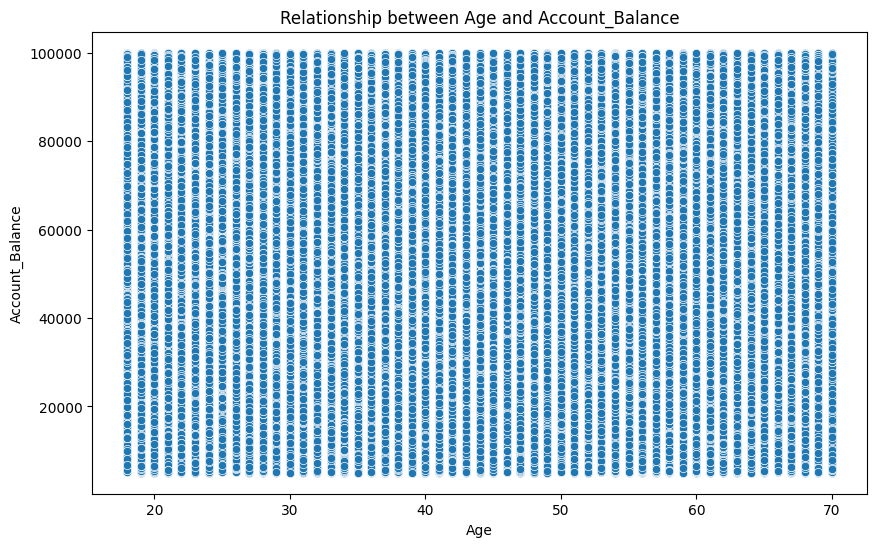

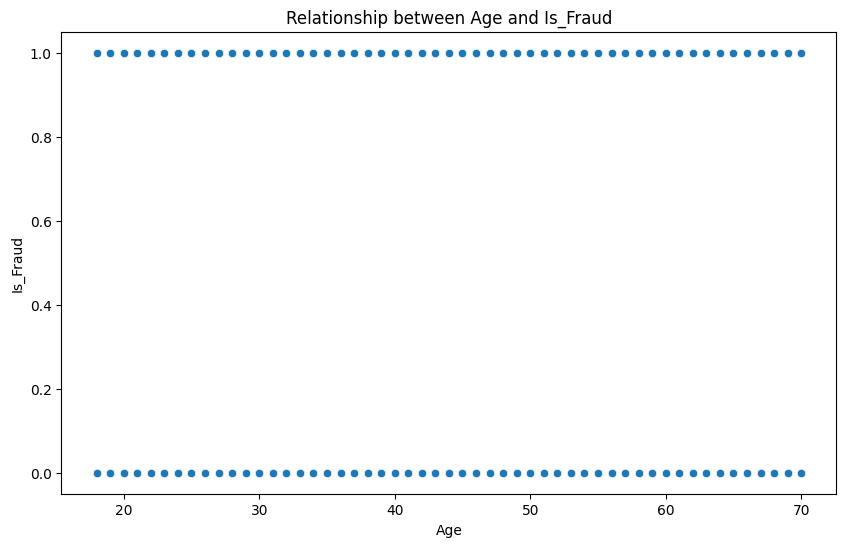

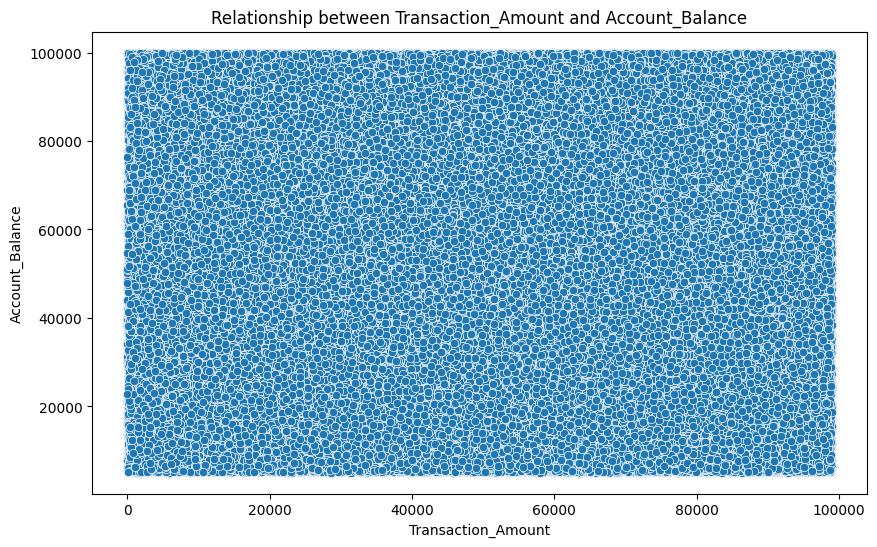

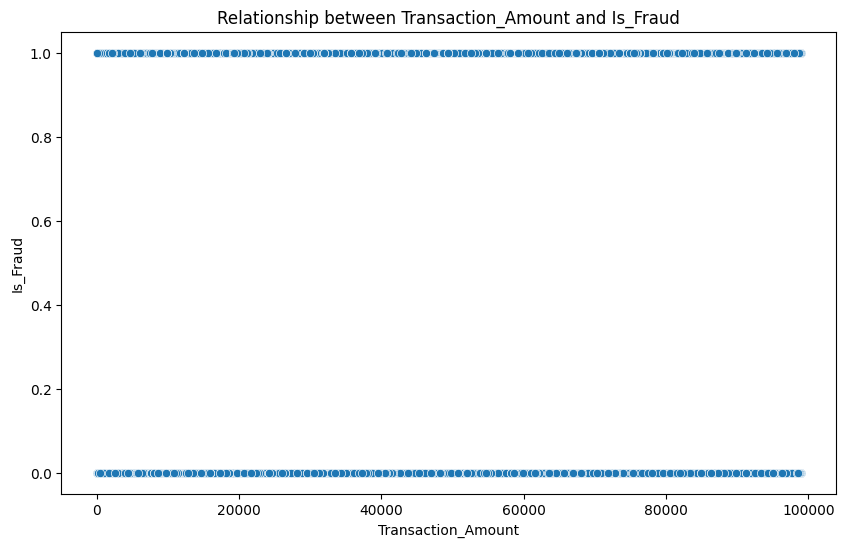

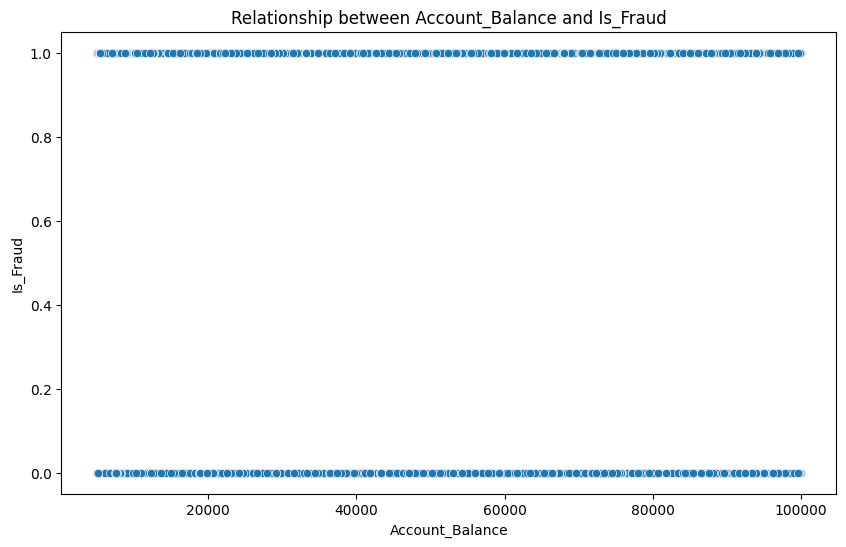

/tmp/ipykernel_424/637701373.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Is_Fraud', y=col, palette='viridis')


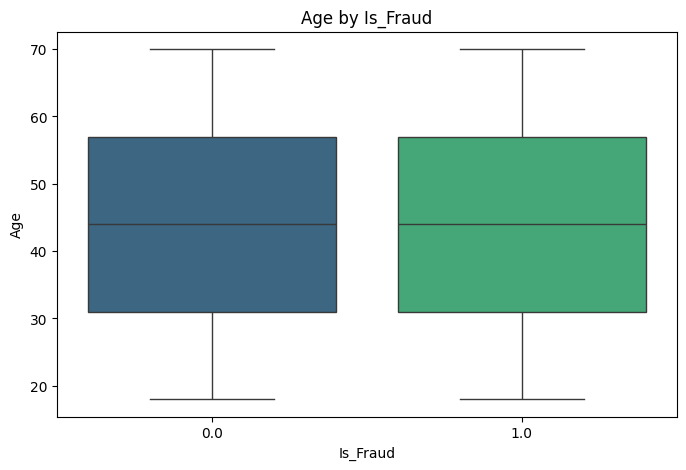

/tmp/ipykernel_424/637701373.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Is_Fraud', y=col, palette='viridis')


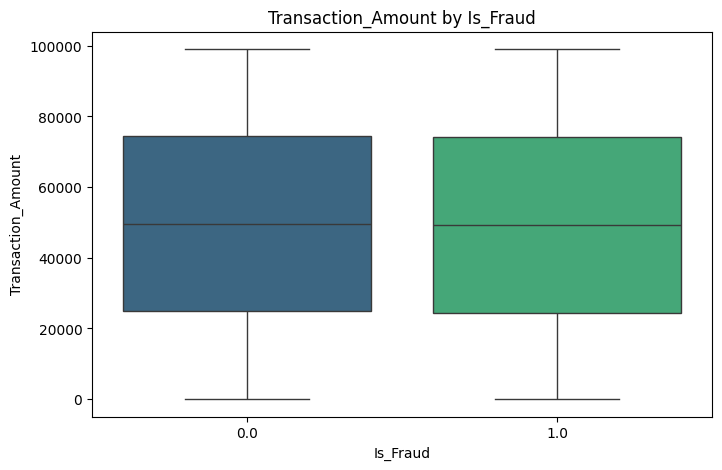

/tmp/ipykernel_424/637701373.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Is_Fraud', y=col, palette='viridis')


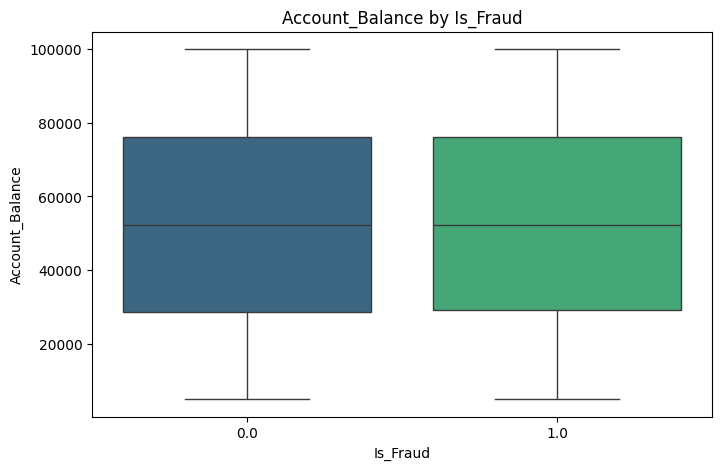

/tmp/ipykernel_424/637701373.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Is_Fraud', y=col, palette='viridis')


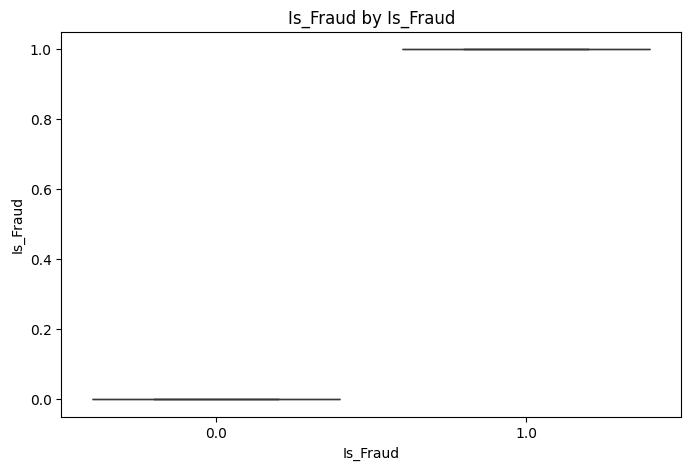

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(df.corr(numeric_only=True), dtype=bool))
sns.heatmap(df.corr(numeric_only=True), mask=mask, annot=True, fmt=".2f", cmap='viridis', center=0)
plt.title('Correlation Matrix Heatmap')
plt.show()

# Feature Correlation with Target
corr_with_target = df.corr(numeric_only=True)['Is_Fraud'].drop('Is_Fraud').sort_values(ascending=False)
print(corr_with_target)
plt.figure(figsize=(10, 6))
corr_with_target.plot(kind='bar', color='steelblue')
plt.title('Feature Correlation with Is_Fraud')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# Pair Plot
sns.pairplot(df[Numerical_Variables], diag_kind='kde')
plt.suptitle('Pair Plot of Numerical Features', y=1.02)
plt.show()

# Histograms and Violin Plots for Numerical Variables
for col in Numerical_Variables:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {col}')
    sns.violinplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Violin Plot of {col}')
    plt.show()

# Scatter Plots for Bivariate Analysis
Bivariate_Numericals = list(combinations(Numerical_Variables, 2))
for x_col, y_col in Bivariate_Numericals:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x=x_col, y=y_col)
    plt.title(f'Relationship between {x_col} and {y_col}')
    plt.show()

# Boxplots: Numerical Features vs Target (Group-wise Comparison)
for col in Numerical_Variables:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='Is_Fraud', y=col, palette='viridis')
    plt.title(f'{col} by Is_Fraud')
    plt.show()




In [ ]:
# Count Plots for Categorical Variables
for col in Categorical_Variables:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=col,hue=col, palette='viridis',legend=False)
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
# Pie Charts for Categorical Variables
plt.figure(figsize=(15, 15))
for i, item in enumerate(Categorical_Variables, start=1):
    counts = df[item].value_counts()
    plt.subplot(1, len(Categorical_Variables), i)
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
    plt.title(f"Pie Chart for {item}")
plt.tight_layout()
plt.show()

In [ ]:
#%% 4. INFERENTIAL STATISTICS
import scipy.stats as stats
# Normality Testing (Shapiro)
for col in Numerical_Variables:
    stat, p = stats.shapiro(df[col].dropna())
    print(f'Shapiro Test for {col}: Statistics={stat:.3f}, p-value={p:.3f}')

In [ ]:
X = df.drop(columns=['Is_Fraud'])
y = df['Is_Fraud']


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% Training, 20% Testing
    random_state=42,     # For reproducibility
    stratify=y           # Keeps fraud/non-fraud ratio balanced in both sets
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("Training target distribution:\n", y_train.value_counts())
print("Testing target distribution:\n", y_test.value_counts())

In [ ]:
#1- import required libraries

import pandas as pd
from sklearn.model_selection import train_test_split

#2- load dataset
df = pd.read_csv("Bank_Transaction_Fraud_Detection.csv")

#3- inspect the data
print(df.head())
print(df.info())
print(df.shape)


#4- separate features (x) and target (y)

X = df.drop("Fraud", axis=1)   # Features
y = df["Fraud"]                # Target variable

#5- split the data(Train & Test)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% test, 80% train
    random_state=42,    # for reproducibility
    stratify=y          # important for fraud datasets
)


#6- checking the results

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


#7- save the split dataset

train_data = pd.concat([X_train, y_train], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

train_data.to_csv("train_data.csv", index=False)
test_data.to_csv("test_data.csv", index=False)

SyntaxError: '(' was never closed (545663137.py, line 22)